## Load dataset

In [ ]:
import os
import pandas as pd
import numpy as np
import glob
from tqdm import tqdm
import kagglehub
import matplotlib.pyplot as py
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb


if os.path.exists('/kaggle/input'):
    BASE_PATH = '/kaggle/input/datasets/yyc023/2026-dm-assignment3'
else:
    # *** Change PATH here***
    BASE_PATH = './data' 

train_pattern = os.path.join(BASE_PATH, 'train/train/User_*/*.csv')
test_pattern = os.path.join(BASE_PATH, 'test/test/User_*/*.csv')

train_files = glob.glob(train_pattern)
test_files = glob.glob(test_pattern)

if len(train_files) == 0:
    print(f"❌ Error：Can not find file！Please change BASE_PATH. Current targetd path：{train_pattern}")
else:
    print(f"✅ Find {len(train_files)} traing files.")

✅ Find 11020 traing files.


## EDA

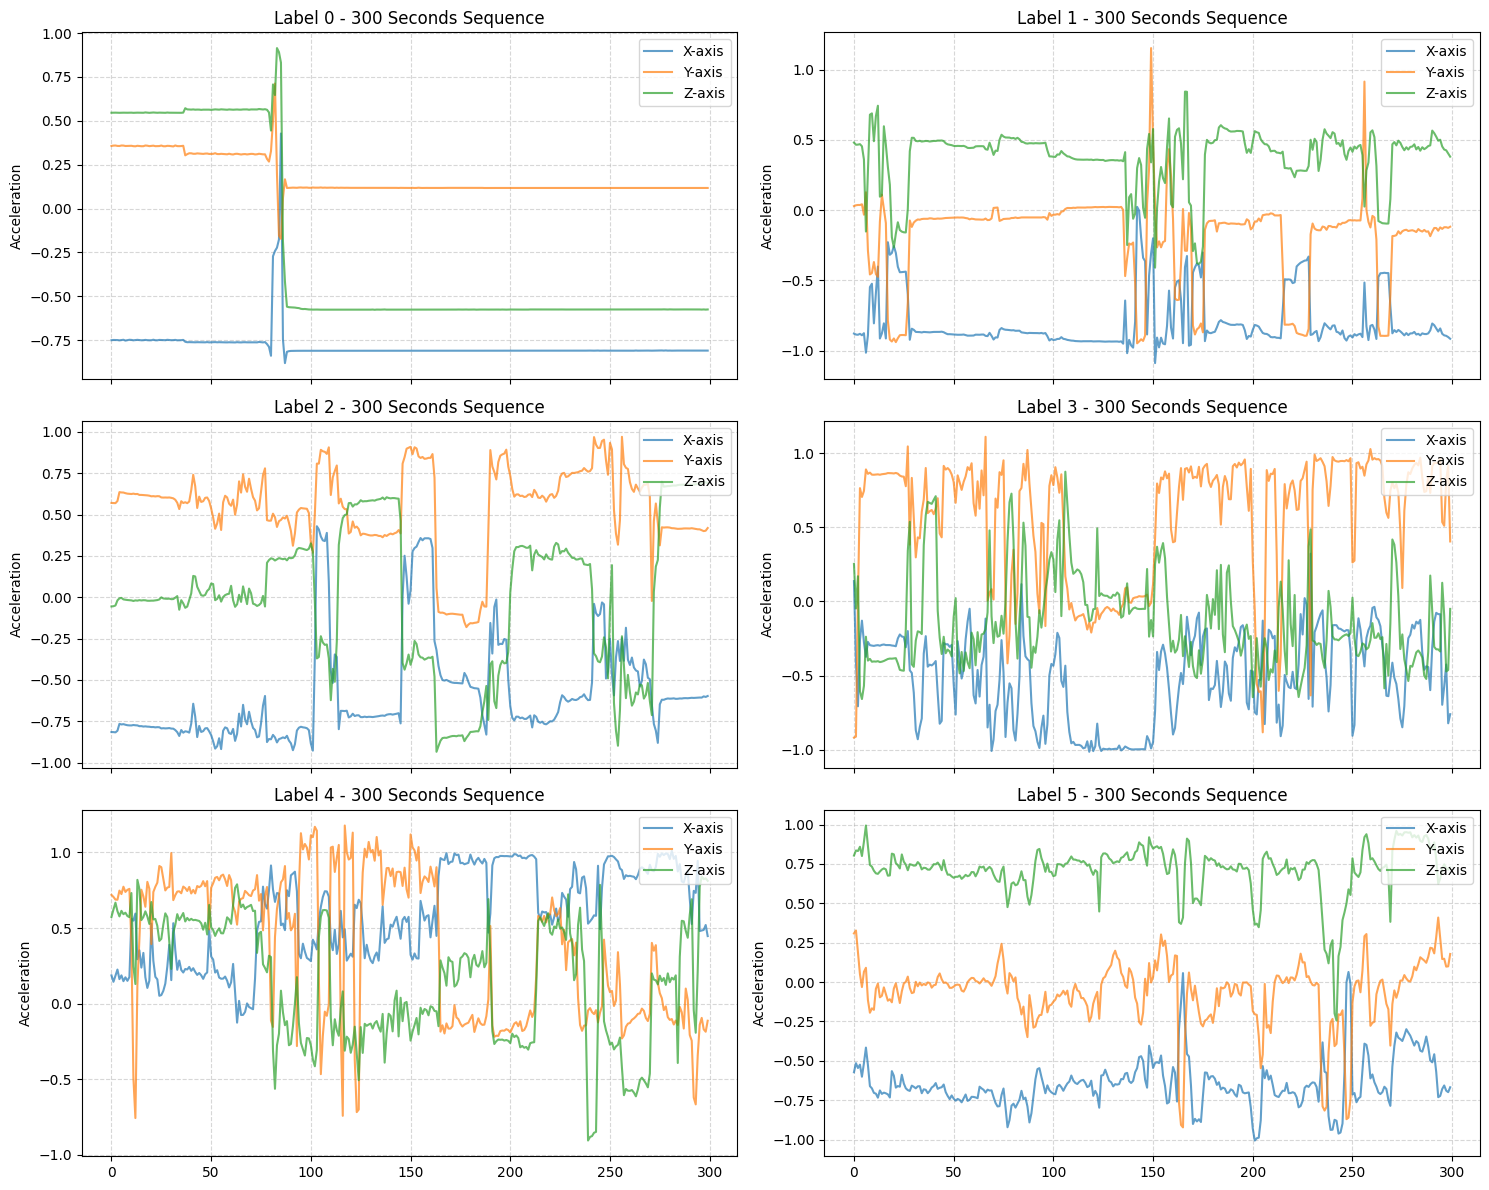

In [2]:
## Random label observation

sample_dict = {}
for f in train_files:
    label = pd.read_csv(f, nrows=1)['label'].iloc[0] # Pick label from the first row
    if label not in sample_dict:
        sample_dict[label] = f
    if len(sample_dict) == 6: break # Stop when get all 6 category

fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
axes = axes.flatten()
for i, label in enumerate(sorted(sample_dict.keys())):
    df_sample = pd.read_csv(sample_dict[label])
    
    axes[i].plot(df_sample['index'], df_sample['mean_x'], label='X-axis', alpha=0.7)    
    axes[i].plot(df_sample['index'], df_sample['mean_y'], label='Y-axis', alpha=0.7)
    axes[i].plot(df_sample['index'], df_sample['mean_z'], label='Z-axis', alpha=0.7)
    
    axes[i].set_title(f"Label {label} - 300 Seconds Sequence")
    axes[i].set_ylabel("Acceleration")
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


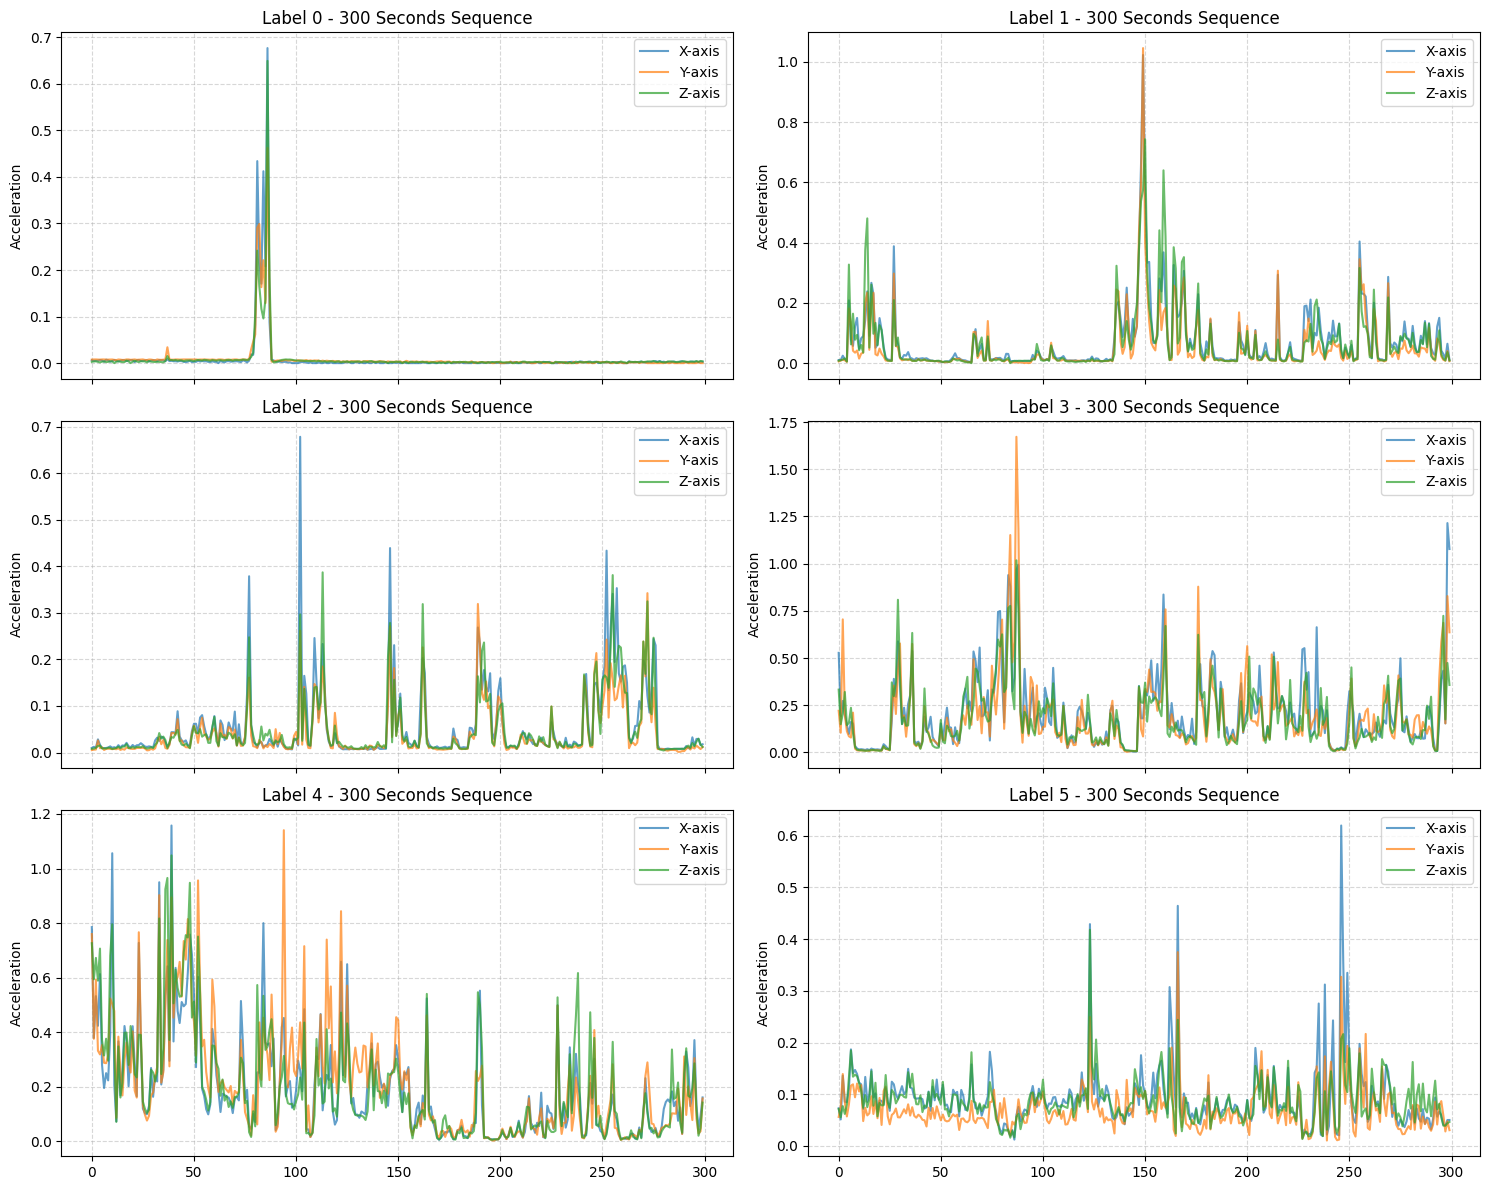

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
axes = axes.flatten()
for i, label in enumerate(sorted(sample_dict.keys())):
    df_sample = pd.read_csv(sample_dict[label])
    
    axes[i].plot(df_sample['index'], df_sample['std_x'], label='X-axis', alpha=0.7)
    axes[i].plot(df_sample['index'], df_sample['std_y'], label='Y-axis', alpha=0.7)
    axes[i].plot(df_sample['index'], df_sample['std_z'], label='Z-axis', alpha=0.7)
    
    axes[i].set_title(f"Label {label} - 300 Seconds Sequence")
    axes[i].set_ylabel("Acceleration")
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [4]:
def slope(y):
    """Calculate sliding window's slope"""
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x, y)
    return slope
    
def get_mean_features(file_list, is_train=True):
    data = []
    for f in tqdm(file_list):
        path_parts = f.split(os.sep)
        user_id = path_parts[-2]
        file_id = int(path_parts[-1].split('.')[0])
        
        df = pd.read_csv(f)

        # ===== magnitude =====
        df['magnitude'] = np.sqrt(df['mean_x']**2 +df['mean_y']**2 +df['mean_z']**2)
        
        # ===== jerk & rolling=====
        for ax in ['x', 'y', 'z']:
            df[f'jerk_{ax}'] = df[f'mean_{ax}'].diff().fillna(0)
            df[f'mean_{ax}_roll5'] = df[f'mean_{ax}'].rolling(window=5).mean().bfill()

        with np.errstate(all='ignore'):

            mean_std_x = df['mean_x'].std()
            mean_std_y = df['mean_y'].std()
            mean_std_z = df['mean_z'].std()
                
            res = {
                'user_id': user_id,
                'Id': file_id,
                'mean_x_avg': df['mean_x'].mean(),
                'mean_y_avg': df['mean_y'].mean(),
                'mean_z_avg': df['mean_z'].mean(),
                'mean_x_med': df['mean_x'].median(),
                'mean_y_med': df['mean_y'].median(),
                'mean_z_med': df['mean_z'].median(),
                'std_x_avg': df['std_x'].mean(),
                'std_y_avg': df['std_y'].mean(),
                'std_z_avg': df['std_z'].mean(),
                
                # Calculate new feature
                # mean_n_std
                'mean_x_std': df['mean_x'].std(),
                'mean_y_std': df['mean_y'].std(),
                'mean_z_std': df['mean_z'].std(),
                
                # range
                'range_x': df['mean_x'].max() - df['mean_x'].min(), 
                'range_y': df['mean_y'].max() - df['mean_y'].min(),
                'range_z': df['mean_z'].max() - df['mean_z'].min(),
    
                 # magnitude
                'magnitude_mean': df['magnitude'].mean(),
                'magnitude_std': df['magnitude'].std(),
                            
                # jerk
                'jerk_x_std': df['jerk_x'].std(),
                'jerk_y_std': df['jerk_y'].std(),
                'jerk_z_std': df['jerk_z'].std(),
        
                # correlation 
                # 只有當兩軸都有波動(std > 0)時才算 corr，否則直接給 0
                'corr_xy': df['mean_x'].corr(df['mean_y']) if mean_std_x > 0 and mean_std_y > 0 else 0.0,
                'corr_xz': df['mean_x'].corr(df['mean_z']) if mean_std_x > 0 and mean_std_z > 0 else 0.0,
                'corr_yz': df['mean_y'].corr(df['mean_z']) if mean_std_y > 0 and mean_std_z > 0 else 0.0,

                # rolling and trend
                'mean_x_roll5_std' : df['mean_x_roll5'].std(),
                'mean_x_roll5_trend' : slope(df['mean_x_roll5'].values),
                'mean_y_roll5_std' : df['mean_y_roll5'].std(),
                'mean_y_roll5_trend' : slope(df['mean_y_roll5'].values),
                'mean_z_roll5_std' : df['mean_z_roll5'].std(),
                'mean_z_roll5_trend' : slope(df['mean_z_roll5'].values)
            }
            for k, v in res.items():
                    if isinstance(v, (float, np.float64, np.float32)):
                        if np.isnan(v) or np.isinf(v):
                            res[k] = 0.0
        if is_train:
            res['Label'] = df['label'].iloc[0]
        data.append(res)
    return pd.DataFrame(data)

eda_df = get_mean_features(train_files, is_train=True)
eda_df = eda_df.sort_values(['user_id', 'Id']).reset_index(drop=True)
eda_df.head()

100%|██████████| 11020/11020 [03:23<00:00, 54.17it/s]


,user_id,Id,mean_x_avg,mean_y_avg,mean_z_avg,mean_x_med,mean_y_med,mean_z_med,std_x_avg,std_y_avg,...,corr_xy,corr_xz,corr_yz,mean_x_roll5_std,mean_x_roll5_trend,mean_y_roll5_std,mean_y_roll5_trend,mean_z_roll5_std,mean_z_roll5_trend,Label
0,User_001,1,-0.474944,-0.531549,0.659618,-0.475184,-0.532570,0.659098,0.007086,0.004389,...,-0.672841,-0.489820,0.898587,0.002057,-0.000014,0.002822,0.000029,0.001344,1.354620e-05,0
1,User_001,2,-0.477411,-0.526162,0.662113,-0.478000,-0.526124,0.661752,0.006512,0.006218,...,-0.540687,-0.070063,0.802157,0.001913,0.000004,0.002204,0.000008,0.001727,7.693631e-06,0
2,User_001,3,-0.477836,-0.521952,0.665407,-0.478405,-0.520462,0.665601,0.006584,0.005477,...,-0.913854,-0.785442,0.881651,0.000829,-0.000007,0.000971,0.000007,0.000523,1.898885e-06,0
3,User_001,4,-0.476572,-0.518352,0.671225,-0.477044,-0.517802,0.673961,0.006836,0.003335,...,0.126408,0.548904,0.833940,0.002092,0.000018,0.001815,0.000018,0.004043,3.873914e-05,0
4,User_001,5,-0.476293,-0.516450,0.674178,-0.476830,-0.516726,0.674233,0.007244,0.003539,...,-0.782942,-0.513768,0.602880,0.000644,-0.000003,0.000340,0.000001,0.000119,1.460367e-07,0


/tmp/ipykernel_57/3062680852.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y='mean_y_avg', data=eda_df, palette='pastel')


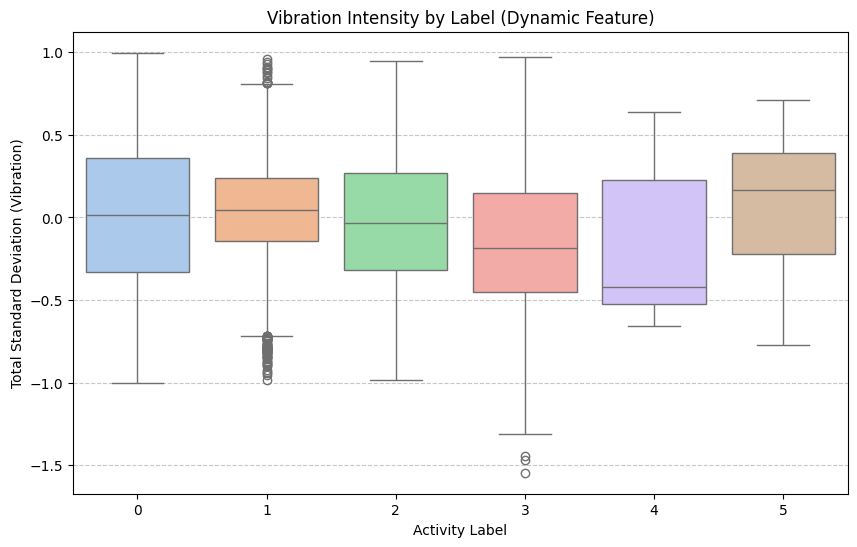

In [5]:
## 1. Total std comparison
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='Label', y='mean_y_avg', data=eda_df, palette='pastel')
plt.title('Vibration Intensity by Label (Dynamic Feature)')
plt.ylabel('Total Standard Deviation (Vibration)')
plt.xlabel('Activity Label')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

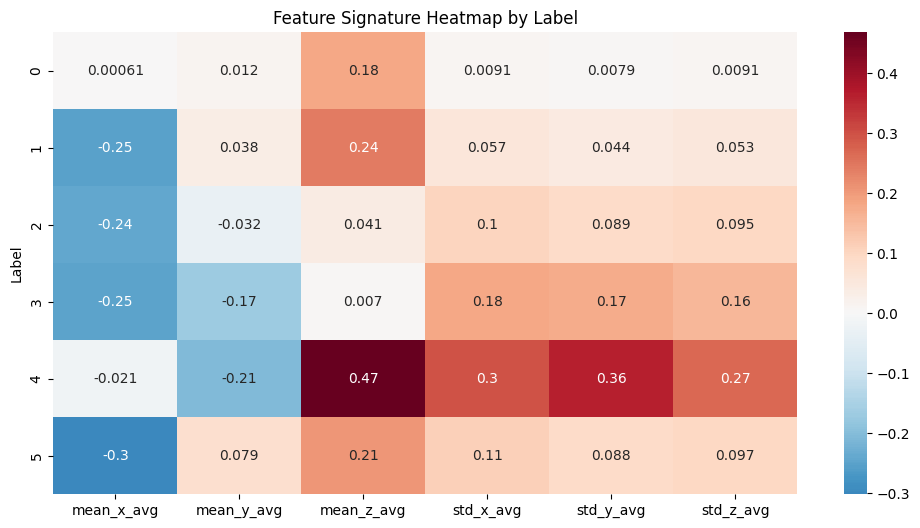

In [6]:
## 2. Mean Heatmap by label
fingerprint = eda_df.groupby('Label')[['mean_x_avg', 'mean_y_avg', 'mean_z_avg',
                                       'std_x_avg', 'std_y_avg', 'std_z_avg']].mean()
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.heatmap(fingerprint, annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Signature Heatmap by Label')
plt.show()

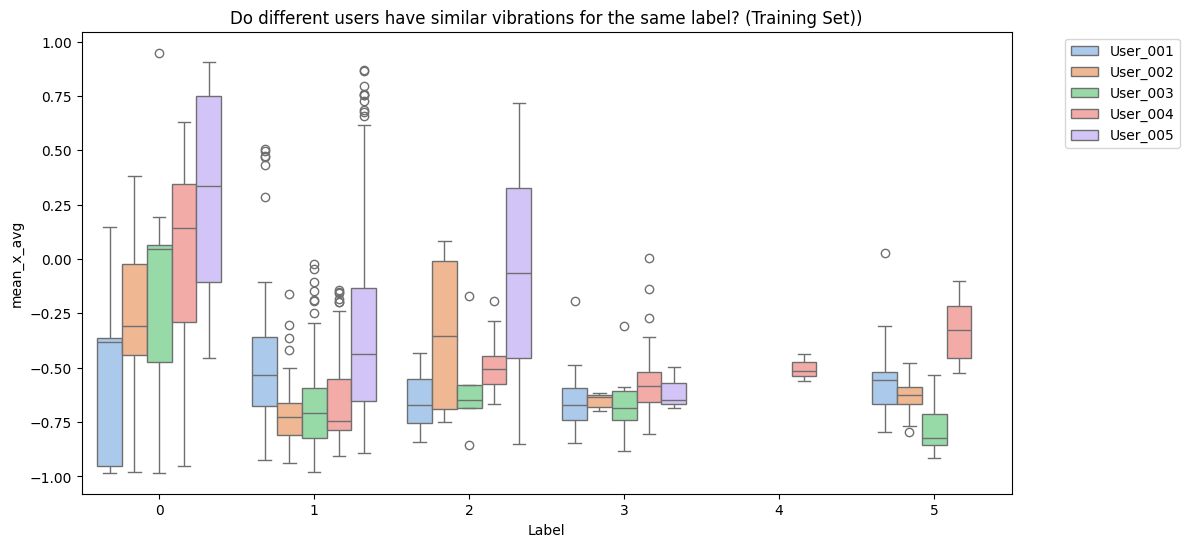

In [7]:
# Compare label with random 5 users
selected_users = eda_df['user_id'].unique()[:5] # 抓前 5 個 User
sub_df = eda_df[eda_df['user_id'].isin(selected_users)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='Label', y='mean_x_avg', hue='user_id', data=sub_df, palette='pastel')
plt.title('Do different users have similar vibrations for the same label? (Training Set))')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

/tmp/ipykernel_57/1680994713.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')


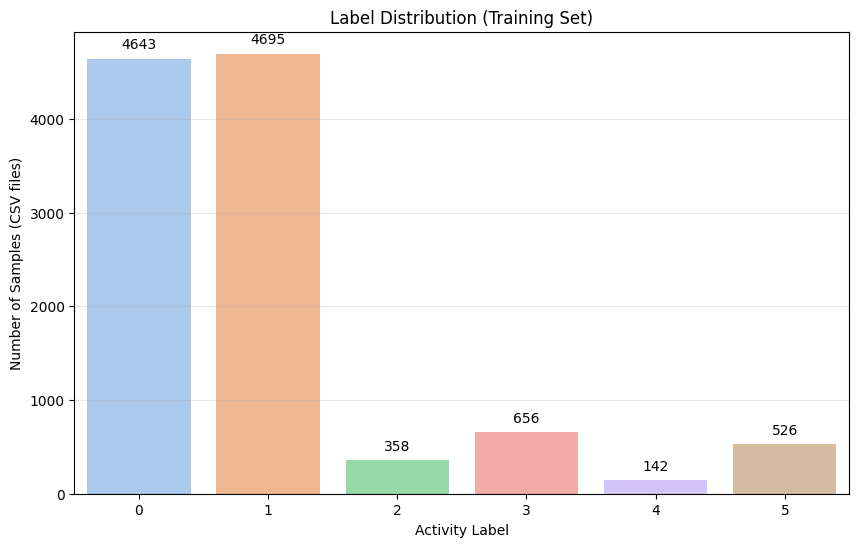

Label Percentage：
Label
0    42.132486
1    42.604356
2     3.248639
3     5.952813
4     1.288566
5     4.773140
Name: proportion, dtype: float64


In [8]:
label_counts=eda_df['Label'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='pastel')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
    
plt.title('Label Distribution (Training Set)')
plt.xlabel('Activity Label')
plt.ylabel('Number of Samples (CSV files)')
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Label Percentage：")
print(eda_df['Label'].value_counts(normalize=True).sort_index() * 100 )

## Baseline model: Random Forest

In [9]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.base import clone
import seaborn as sns

def run_kfold(X, y, groups, model):
    gkf = GroupKFold(n_splits=5)
    y_true_accumulated = []
    y_pred_accumulated = []
    
    for train_idx, val_idx in gkf.split(X, y, groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        m = clone(model).fit(X_train, y_train)
        
        fold_preds = m.predict(X_val)
        
        y_true_accumulated.extend(y_val)
        y_pred_accumulated.extend(fold_preds)
        
        score = accuracy_score(y_val, fold_preds)
        print(f"Fold result: {score:.4f}")
        
    return y_true_accumulated, y_pred_accumulated, m

def feature_importance(model, X_column):
    
    importances = model.feature_importances_
    feat_importances = pd.Series(importances, index=X_column)
    top_feats = feat_importances.nlargest(30).sort_values(ascending=True) 
    
    # Plot
    plt.figure(figsize=(8, 6))
    top_feats.plot(kind='barh', color='skyblue', edgecolor='navy')
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.title('Important Features')
    
    for i, v in enumerate(top_feats):
            plt.text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')
        
    plt.tight_layout()
    plt.show()

    print("\n")


def evaluate_model(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    
    # Calculate macro F1 score
    m_f1 = f1_score(y_true, y_pred, average='macro')
    print(f" Overall Macro F1-score: {m_f1:.4f}\n\n")
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=range(6), yticklabels=range(6))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix')
    plt.show()

Fold result: 0.8269
Fold result: 0.7970
Fold result: 0.8251
Fold result: 0.8293
Fold result: 0.7936


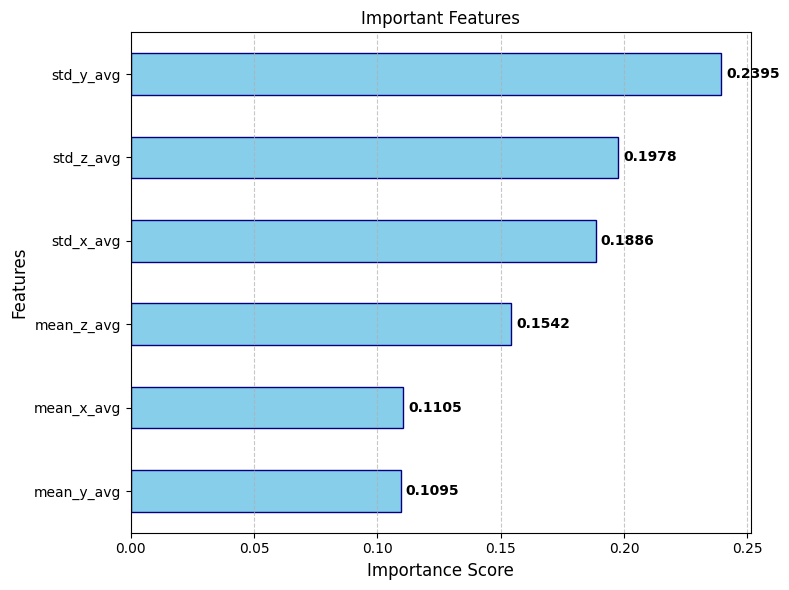



              precision    recall  f1-score   support

           0       0.91      0.91      0.91      4643
           1       0.77      0.88      0.82      4695
           2       0.22      0.03      0.06       358
           3       0.58      0.63      0.60       656
           4       0.81      0.58      0.68       142
           5       0.52      0.13      0.21       526

    accuracy                           0.81     11020
   macro avg       0.64      0.53      0.55     11020
weighted avg       0.79      0.81      0.79     11020

 Overall Macro F1-score: 0.5489




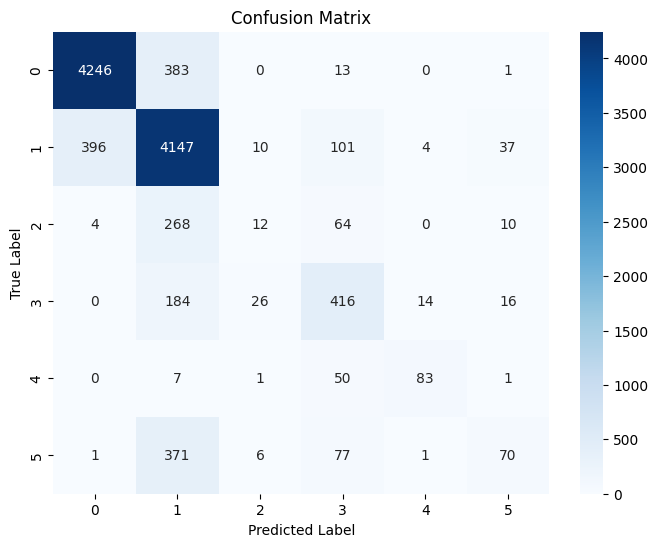

In [10]:
X = eda_df[['mean_x_avg', 'mean_y_avg', 'mean_z_avg', 'std_x_avg', 'std_y_avg', 'std_z_avg']]
y = eda_df['Label']
groups = eda_df['user_id']

rf = RandomForestClassifier(n_estimators=250, 
                                   class_weight='balanced', 
                                   random_state=42, 
                                   n_jobs=-1)


y_val_true, y_val_pred, model = run_kfold(X, y, groups, rf)
feature_importance(model, X.columns)
evaluate_model(y_val_true, y_val_pred)

## --> Change to LightGBM

Fold result: 0.7711
Fold result: 0.7535
Fold result: 0.7958
Fold result: 0.7756
Fold result: 0.7416


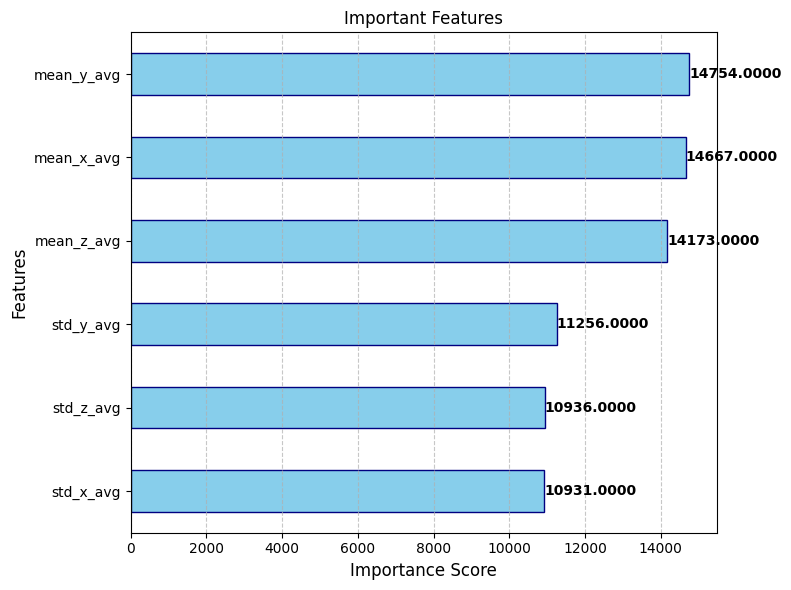



              precision    recall  f1-score   support

           0       0.91      0.92      0.91      4643
           1       0.84      0.71      0.77      4695
           2       0.15      0.26      0.19       358
           3       0.51      0.68      0.58       656
           4       0.80      0.66      0.72       142
           5       0.29      0.39      0.33       526

    accuracy                           0.77     11020
   macro avg       0.58      0.60      0.59     11020
weighted avg       0.80      0.77      0.78     11020

 Overall Macro F1-score: 0.5851




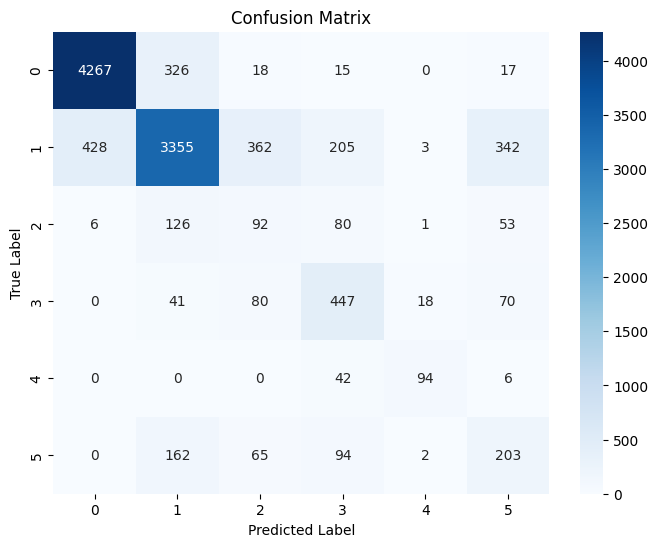

In [11]:
X = eda_df[['mean_x_avg', 'mean_y_avg', 'mean_z_avg', 'std_x_avg', 'std_y_avg', 'std_z_avg']]
y = eda_df['Label']
groups = eda_df['user_id']

lgbm = lgb.LGBMClassifier(n_estimators=1000,
    learning_rate=0.02,
    num_leaves=15,
    max_depth=5,
    min_child_samples=30,
    subsample=0.7,
    subsample_freq=1,
    colsample_bytree=0.6,
    reg_alpha=1.0,
    reg_lambda=1.0,
    class_weight='balanced',
    objective='multiclass',
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)


y_val_true, y_val_pred, model = run_kfold(X, y, groups, lgbm)
feature_importance(model, X.columns)
evaluate_model(y_val_true, y_val_pred)

## Feature Engineering

In [12]:
print(eda_df.columns)

Index(['user_id', 'Id', 'mean_x_avg', 'mean_y_avg', 'mean_z_avg', 'mean_x_med',
       'mean_y_med', 'mean_z_med', 'std_x_avg', 'std_y_avg', 'std_z_avg',
       'mean_x_std', 'mean_y_std', 'mean_z_std', 'range_x', 'range_y',
       'range_z', 'magnitude_mean', 'magnitude_std', 'jerk_x_std',
       'jerk_y_std', 'jerk_z_std', 'corr_xy', 'corr_xz', 'corr_yz',
       'mean_x_roll5_std', 'mean_x_roll5_trend', 'mean_y_roll5_std',
       'mean_y_roll5_trend', 'mean_z_roll5_std', 'mean_z_roll5_trend',
       'Label'],
      dtype='object')


Fold result: 0.8492
Fold result: 0.8242
Fold result: 0.8414
Fold result: 0.8384
Fold result: 0.8193


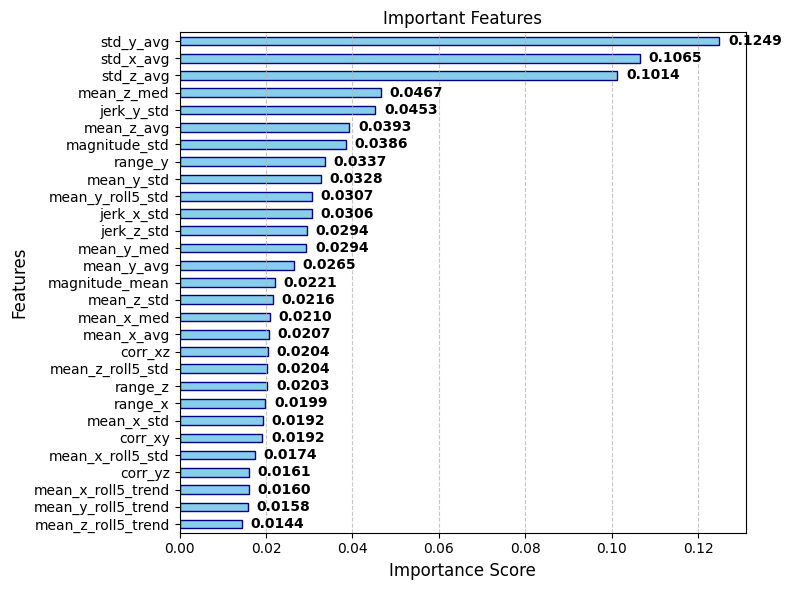



              precision    recall  f1-score   support

           0       0.92      0.93      0.93      4643
           1       0.78      0.90      0.84      4695
           2       0.20      0.01      0.01       358
           3       0.63      0.66      0.64       656
           4       0.89      0.65      0.76       142
           5       0.86      0.20      0.33       526

    accuracy                           0.83     11020
   macro avg       0.71      0.56      0.58     11020
weighted avg       0.82      0.83      0.81     11020

 Overall Macro F1-score: 0.5841




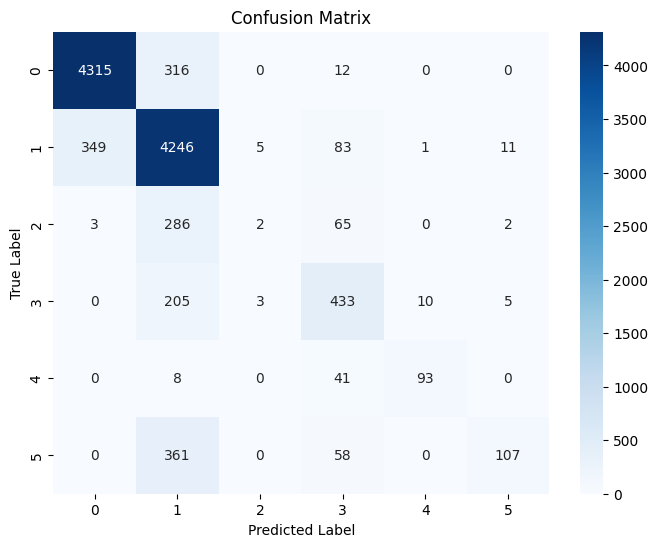

In [ ]:
# All feature + Random Forest
X = eda_df[['mean_x_avg', 'mean_y_avg', 'mean_z_avg', 'mean_x_med',
       'mean_y_med', 'mean_z_med', 'std_x_avg', 'std_y_avg', 'std_z_avg',
       'mean_x_std', 'mean_y_std', 'mean_z_std', 'range_x', 'range_y',
       'range_z', 'magnitude_mean', 'magnitude_std', 'jerk_x_std',
       'jerk_y_std', 'jerk_z_std', 'corr_xy', 'corr_xz', 'corr_yz',
       'mean_x_roll5_std', 'mean_x_roll5_trend', 'mean_y_roll5_std',
       'mean_y_roll5_trend', 'mean_z_roll5_std', 'mean_z_roll5_trend'
        ]]
y = eda_df['Label']
groups = eda_df['user_id']

rf = RandomForestClassifier(n_estimators=250, 
                                   class_weight='balanced', 
                                   random_state=42, 
                                   n_jobs=-1)

y_val_true, y_val_pred, model = run_kfold(X, y, groups, rf)
feature_importance(model, X.columns)
evaluate_model(y_val_true, y_val_pred)

Fold result: 0.8255
Fold result: 0.8192
Fold result: 0.8427
Fold result: 0.8503
Fold result: 0.8017


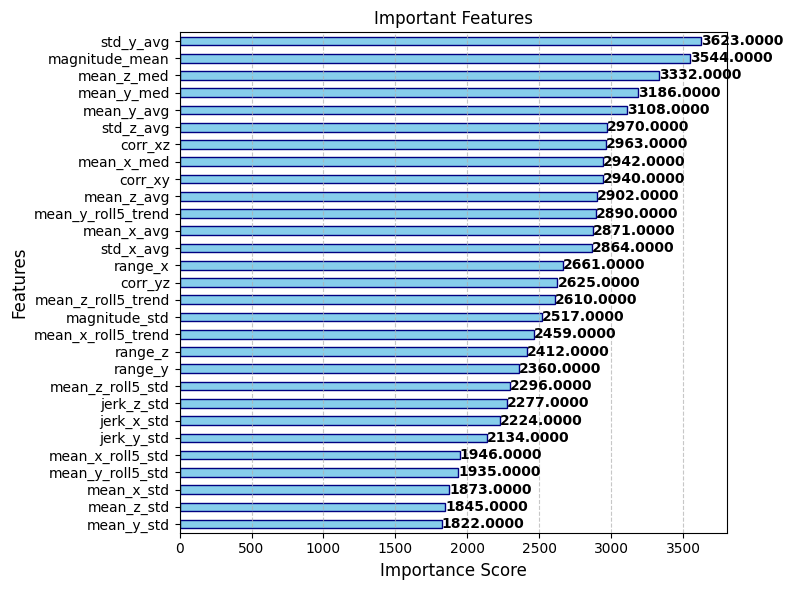



              precision    recall  f1-score   support

           0       0.93      0.94      0.93      4643
           1       0.86      0.83      0.84      4695
           2       0.22      0.21      0.22       358
           3       0.54      0.69      0.61       656
           4       0.84      0.72      0.78       142
           5       0.51      0.47      0.49       526

    accuracy                           0.83     11020
   macro avg       0.65      0.64      0.64     11020
weighted avg       0.83      0.83      0.83     11020

 Overall Macro F1-score: 0.6432




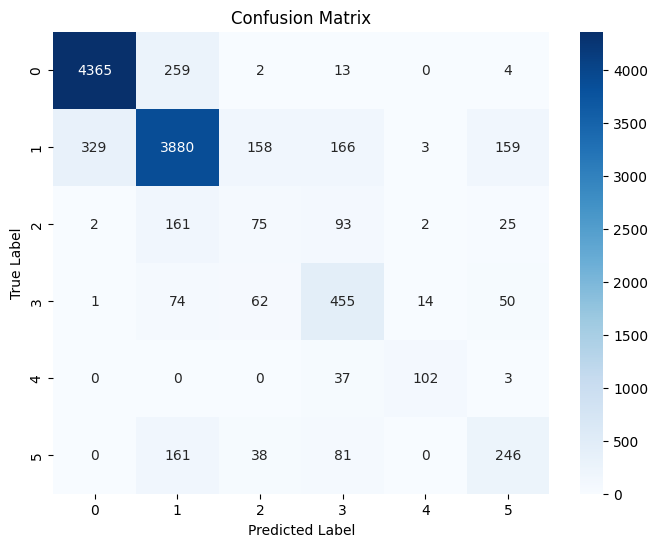

In [ ]:
# All feature + lgbm
X = eda_df[['mean_x_avg', 'mean_y_avg', 'mean_z_avg', 'mean_x_med',
       'mean_y_med', 'mean_z_med', 'std_x_avg', 'std_y_avg', 'std_z_avg',
       'mean_x_std', 'mean_y_std', 'mean_z_std', 'range_x', 'range_y',
       'range_z', 'magnitude_mean', 'magnitude_std', 'jerk_x_std',
       'jerk_y_std', 'jerk_z_std', 'corr_xy', 'corr_xz', 'corr_yz',
       'mean_x_roll5_std', 'mean_x_roll5_trend', 'mean_y_roll5_std',
       'mean_y_roll5_trend', 'mean_z_roll5_std', 'mean_z_roll5_trend'
        ]]
y = eda_df['Label']
groups = eda_df['user_id']

lgbm = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    num_leaves=15,
    max_depth=5,
    min_child_samples=30,
    subsample=0.7,
    subsample_freq=1,
    colsample_bytree=0.6,
    reg_alpha=1.0,
    reg_lambda=1.0,
    class_weight='balanced',
    objective='multiclass',
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)


y_val_true, y_val_pred, model = run_kfold(X, y, groups, lgbm)
feature_importance(model, X.columns)
evaluate_model(y_val_true, y_val_pred)

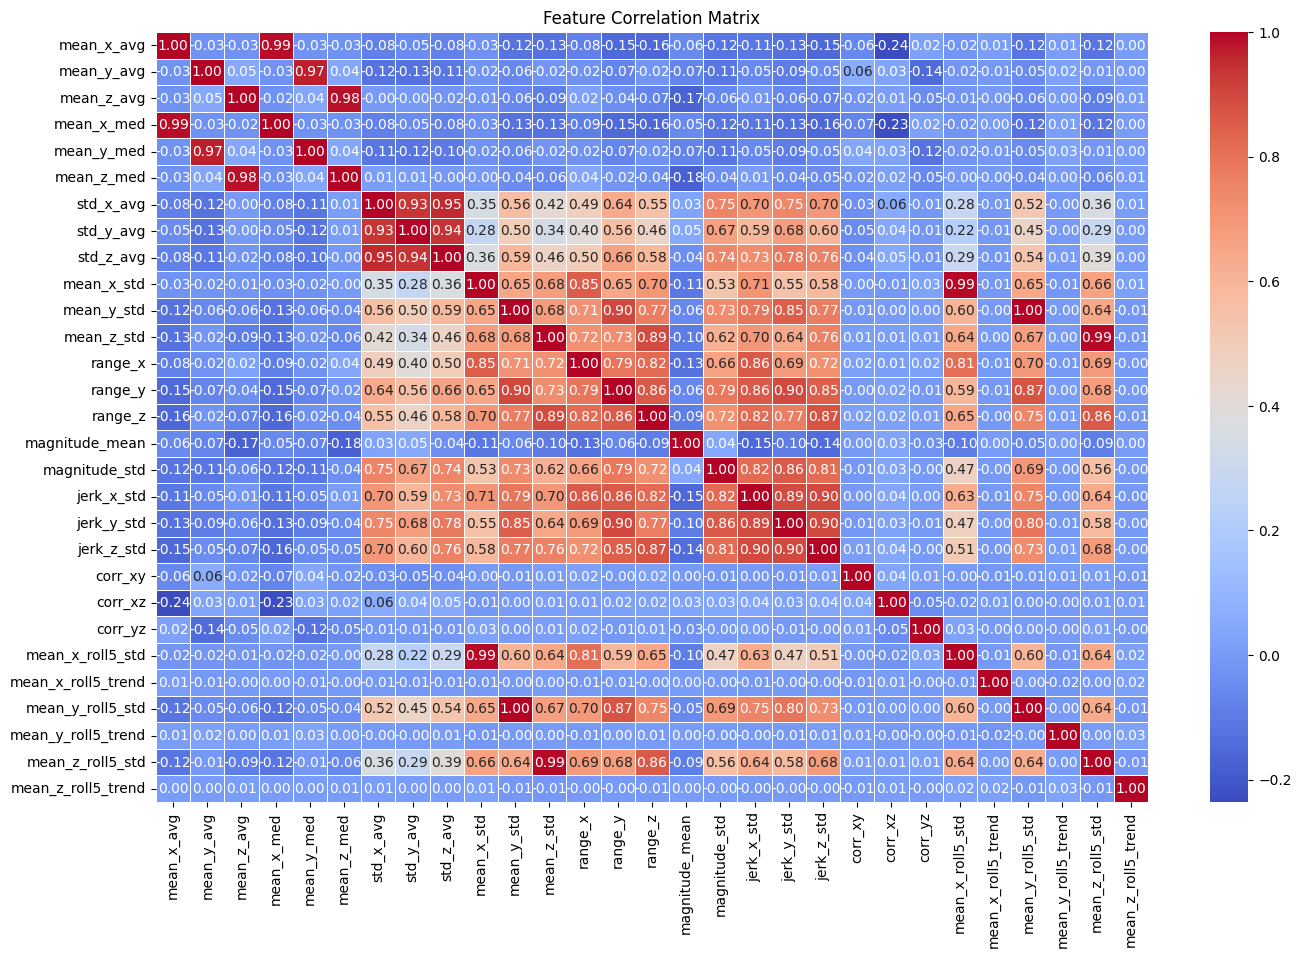

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

features_to_check = [c for c in eda_df.columns if c not in ['Id', 'Label', 'user_id', 'index']]
corr_matrix = eda_df[features_to_check].corr()

# Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

## --> Add sliding window

In [16]:
def sliding_window_features(file_list, window_size, step_size, is_train=True):
    data = []
    for f in tqdm(file_list):
        path_parts = f.split(os.sep)
        user_id = path_parts[-2]
        file_id = int(path_parts[-1].split('.')[0])
        df = pd.read_csv(f)

        # ===== magnitude =====
        df['magnitude'] = np.sqrt(df['mean_x']**2 +df['mean_y']**2 +df['mean_z']**2)
        
        # ===== jerk & rolling=====
        for ax in ['x', 'y', 'z']:
            df[f'jerk_{ax}'] = df[f'mean_{ax}'].diff().fillna(0)
            df[f'mean_{ax}_roll5'] = df[f'mean_{ax}'].rolling(window=5).mean().bfill()
            
        # 如果是模式 1 (不加 sliding window)，強行把 window 設為整個檔案長度
        actual_window = len(df) if window_size is None else window_size
        actual_step = len(df) if step_size is None else step_size

        for start in range(0, len(df) - actual_window + 1, actual_step):
            end = start + actual_window
            w_df = df.iloc[start:end]

            with np.errstate(all='ignore'):

                mean_std_x = w_df['mean_x'].std()
                mean_std_y = w_df['mean_y'].std()
                mean_std_z = w_df['mean_z'].std()
                res = {
                    'user_id': user_id,
                    'Id': file_id,
                    'mean_x_avg': w_df['mean_x'].mean(),
                    'mean_y_avg': w_df['mean_y'].mean(),
                    'mean_z_avg': w_df['mean_z'].mean(),
                    'mean_x_med': w_df['mean_x'].median(),
                    'mean_y_med': w_df['mean_y'].median(),
                    'mean_z_med': w_df['mean_z'].median(),
                    'std_x_avg': w_df['std_x'].mean(),
                    'std_y_avg': w_df['std_y'].mean(),
                    'std_z_avg': w_df['std_z'].mean(),
                    
                    # Calculate new feature
                    # mean_n_std
                    'mean_x_std': w_df['mean_x'].std(),
                    'mean_y_std': w_df['mean_y'].std(),
                    'mean_z_std': w_df['mean_z'].std(),
                    
                    # range
                    'range_x': w_df['mean_x'].max() - w_df['mean_x'].min(), 
                    'range_y': w_df['mean_y'].max() - w_df['mean_y'].min(),
                    'range_z': w_df['mean_z'].max() - w_df['mean_z'].min(),
        
                     # magnitude
                    'magnitude_mean': w_df['magnitude'].mean(),
                    'magnitude_std': w_df['magnitude'].std(),

                    # jerk
                    'jerk_x_std': w_df['jerk_x'].std(),
                    'jerk_y_std': w_df['jerk_y'].std(),
                    'jerk_z_std': w_df['jerk_z'].std(),
            
                    # correlation 
                    # 只有當兩軸都有波動(std > 0)時才算 corr，否則直接給 0
                    'corr_xy': w_df['mean_x'].corr(w_df['mean_y']) if mean_std_x > 0 and mean_std_y > 0 else 0.0,
                    'corr_xz': w_df['mean_x'].corr(w_df['mean_z']) if mean_std_x > 0 and mean_std_z > 0 else 0.0,
                    'corr_yz': w_df['mean_y'].corr(w_df['mean_z']) if mean_std_y > 0 and mean_std_z > 0 else 0.0,
    
                    # rolling and trend
                    'mean_x_roll5_std' : w_df['mean_x_roll5'].std(),
                    'mean_x_roll5_trend' : slope(w_df['mean_x_roll5'].values),
                    'mean_y_roll5_std' : w_df['mean_y_roll5'].std(),
                    'mean_y_roll5_trend' : slope(w_df['mean_y_roll5'].values),
                    'mean_z_roll5_std' : w_df['mean_z_roll5'].std(),
                    'mean_z_roll5_trend' : slope(w_df['mean_z_roll5'].values)
            }
            for k, v in res.items():
                    if isinstance(v, (float, np.float64, np.float32)):
                        if np.isnan(v) or np.isinf(v):
                            res[k] = 0.0
            
            if is_train:
                res['Label'] = w_df['label'].mode()[0]
            data.append(res)
    return pd.DataFrame(data)

In [17]:
def run_kfold_prob(X, y, groups, model, label_weight_dict=None):
    gkf = GroupKFold(n_splits=5)
    classes = np.unique(y)
    all_oof_probs = np.zeros((len(X), len(classes)))

    models = []
    
    for train_idx, val_idx in gkf.split(X, y, groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # 1. 訓練
        m = clone(model).fit(X_train, y_train)
        models.append(m)
    
        # 2. 取得機率預測 (predict_proba)
        all_oof_probs[val_idx] = m.predict_proba(X_val)
        print('Fold finish')
        

    # --- Window-level ---
    prob_df = pd.DataFrame(all_oof_probs, columns=classes)
    prob_df['user_id'] = groups.values
    prob_df['true_label'] = y.values.astype(int)

    return prob_df, models

In [18]:
train_df_windowed_60 = sliding_window_features(train_files, window_size=60, step_size=30, is_train = True)
train_df_windowed_60 = train_df_windowed_60.sort_values(['user_id', 'Id']).reset_index(drop=True)
print(train_df_windowed_60.shape)
train_df_windowed_60.head(5)

100%|██████████| 11020/11020 [07:44<00:00, 23.71it/s]


(99180, 32)


,user_id,Id,mean_x_avg,mean_y_avg,mean_z_avg,mean_x_med,mean_y_med,mean_z_med,std_x_avg,std_y_avg,...,corr_xy,corr_xz,corr_yz,mean_x_roll5_std,mean_x_roll5_trend,mean_y_roll5_std,mean_y_roll5_trend,mean_z_roll5_std,mean_z_roll5_trend,Label
0,User_001,1,-0.471802,-0.535026,0.658259,-0.471618,-0.533497,0.658472,0.006394,0.003578,...,-0.742374,-0.708495,0.921076,0.002018,-0.000110,0.001721,0.000089,0.000412,2.159277e-05,0
1,User_001,1,-0.474512,-0.532925,0.658781,-0.474958,-0.532882,0.658774,0.007245,0.003668,...,-0.851478,-0.752369,0.747359,0.001442,-0.000072,0.000836,0.000037,0.000243,1.182280e-05,0
2,User_001,1,-0.475881,-0.532312,0.658943,-0.476311,-0.532494,0.658916,0.007224,0.004003,...,-0.782621,-0.656554,0.699378,0.000727,-0.000016,0.000379,-0.000002,0.000153,-2.451331e-06,0
3,User_001,1,-0.475611,-0.532435,0.658991,-0.475823,-0.532737,0.658862,0.007296,0.003757,...,-0.797489,-0.523140,0.647863,0.000982,0.000035,0.000427,-0.000010,0.000183,1.328446e-07,0
4,User_001,1,-0.475312,-0.532318,0.659159,-0.475216,-0.532719,0.659088,0.007368,0.003859,...,-0.800368,-0.435615,0.667381,0.000755,-0.000024,0.000443,0.000014,0.000286,3.767092e-06,0


Fold finish
Fold finish
Fold finish
Fold finish
Fold finish


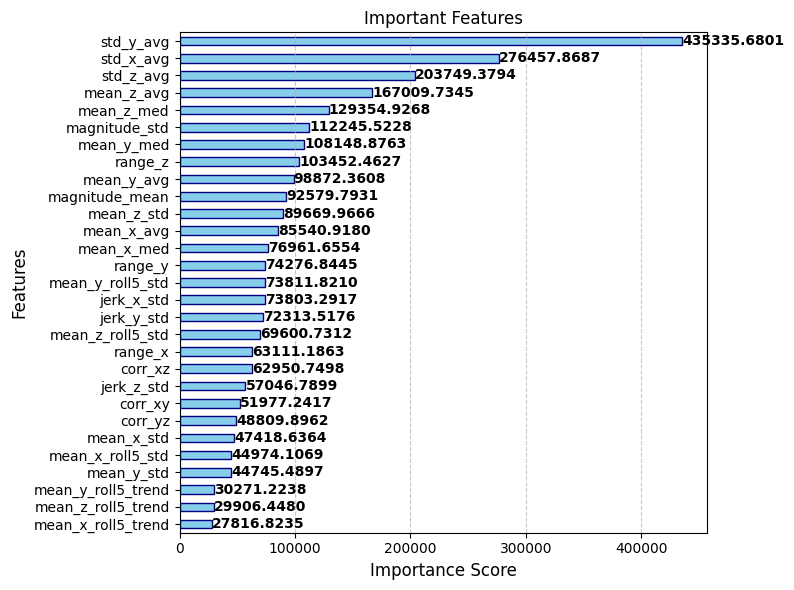



File-level
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      4643
           1       0.84      0.93      0.88      4695
           2       0.31      0.03      0.06       358
           3       0.63      0.70      0.67       656
           4       0.91      0.65      0.76       142
           5       0.90      0.45      0.60       526

    accuracy                           0.87     11020
   macro avg       0.76      0.62      0.65     11020
weighted avg       0.86      0.87      0.86     11020

 Overall Macro F1-score: 0.6536




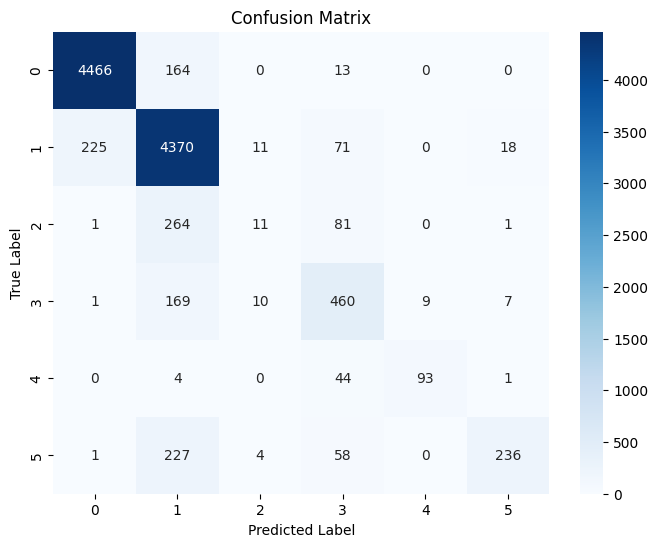

In [19]:
## 2000/0.05  60/30  weight N  --> 0.6536

features = [c for c in train_df_windowed_60.columns if c not in ['Id', 'Label', 'user_id']]
X_train = train_df_windowed_60[features]
y_train = train_df_windowed_60['Label']
groups = train_df_windowed_60['user_id']

lgbm = lgb.LGBMClassifier(
    n_estimators=2000,       
    learning_rate=0.05,     
    num_leaves=31,           
    class_weight='balanced',  
    objective='multiclass',   
    random_state=42,
    n_jobs=-1,
    importance_type='gain',   
    verbosity=-1,             
    colsample_bytree=0.4      
)


prob_df, models = run_kfold_prob(X_train, y_train, groups, lgbm)
feature_importance(models[-1], features)


print("File-level")
classes = models[0].classes_
file_eval_df = prob_df.copy()
file_eval_df['File_Id'] = train_df_windowed_60.loc[X_train.index, 'Id'].values 

# Weighting
# weight_dict= {2: 1.6, 1: 0.9, 3: 1.1, 5:1.1}
# for lbl, w in weight_dict.items():
#         if lbl in file_eval_df.columns:
#             file_eval_df[lbl] = file_eval_df[lbl] * w

file_group = file_eval_df.groupby('File_Id')
y_file_true = file_group['true_label'].first().astype(int)
y_file_pred = file_group[classes].sum().idxmax(axis=1).astype(int)


evaluate_model(y_file_true, y_file_pred)

In [20]:
train_df_windowed = sliding_window_features(train_files, window_size=30, step_size=15, is_train = True)
train_df_windowed = train_df_windowed.sort_values(['user_id', 'Id']).reset_index(drop=True)
print(train_df_windowed.shape)
train_df_windowed.head(5)

100%|██████████| 11020/11020 [14:41<00:00, 12.51it/s]


(209380, 32)


,user_id,Id,mean_x_avg,mean_y_avg,mean_z_avg,mean_x_med,mean_y_med,mean_z_med,std_x_avg,std_y_avg,...,corr_xy,corr_xz,corr_yz,mean_x_roll5_std,mean_x_roll5_trend,mean_y_roll5_std,mean_y_roll5_trend,mean_z_roll5_std,mean_z_roll5_trend,Label
0,User_001,1,-0.470127,-0.536516,0.657908,-0.469897,-0.534275,0.658318,0.005608,0.003786,...,-0.729457,-0.656692,0.938190,0.001309,-0.000129,0.001190,0.000107,0.000296,0.000031,0
1,User_001,1,-0.471735,-0.534710,0.658341,-0.471774,-0.533419,0.658472,0.006613,0.003102,...,-0.755066,-0.759017,0.913230,0.001218,-0.000116,0.001382,0.000134,0.000276,0.000026,0
2,User_001,1,-0.473477,-0.533535,0.658610,-0.474480,-0.533196,0.658588,0.007180,0.003369,...,-0.869356,-0.729527,0.705343,0.001058,-0.000103,0.000481,0.000022,0.000142,0.000006,0
3,User_001,1,-0.474919,-0.532682,0.658794,-0.475653,-0.532728,0.658803,0.007324,0.003918,...,-0.851850,-0.826516,0.755859,0.001024,-0.000096,0.000885,0.000082,0.000218,0.000020,0
4,User_001,1,-0.475546,-0.532314,0.658953,-0.476201,-0.532423,0.658934,0.007310,0.003966,...,-0.778020,-0.724226,0.730869,0.000564,-0.000009,0.000369,-0.000014,0.000101,0.000005,0


Fold finish
Fold finish
Fold finish
Fold finish
Fold finish


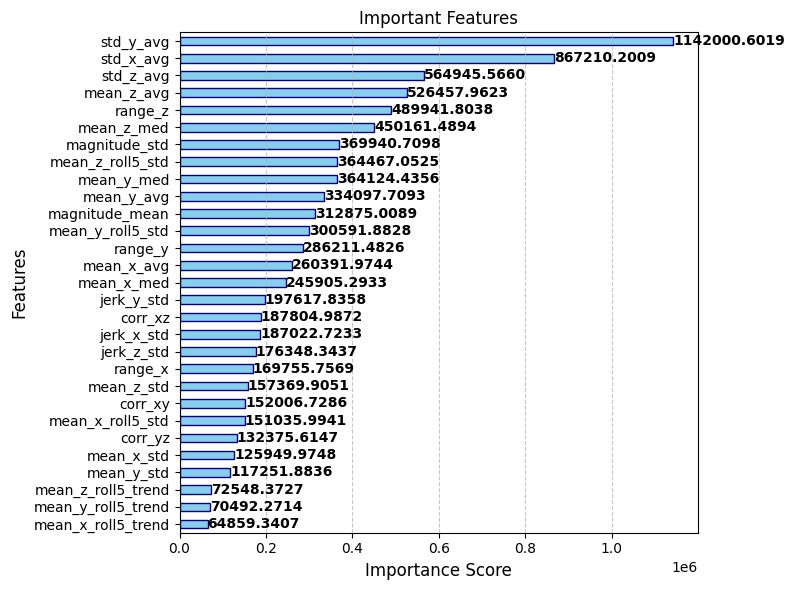



              precision    recall  f1-score   support

           0       0.95      0.97      0.96      4643
           1       0.89      0.89      0.89      4695
           2       0.30      0.16      0.21       358
           3       0.56      0.81      0.66       656
           4       0.92      0.68      0.78       142
           5       0.76      0.53      0.63       526

    accuracy                           0.87     11020
   macro avg       0.73      0.67      0.69     11020
weighted avg       0.87      0.87      0.87     11020

 Overall Macro F1-score: 0.6866




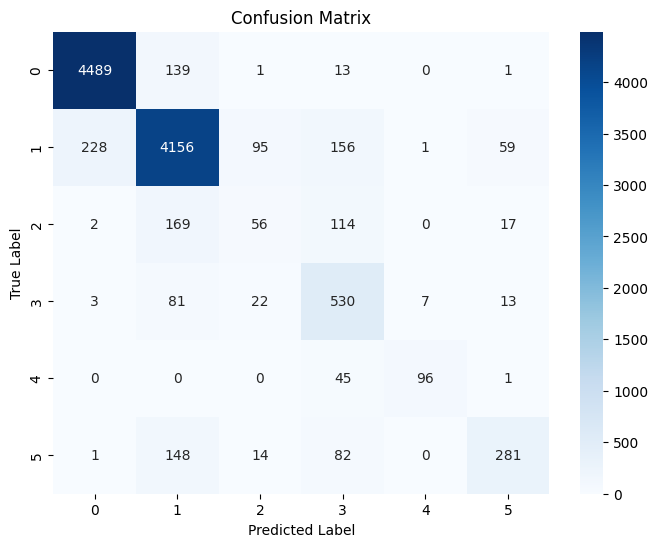

In [21]:
## 2000/0.03  30/15  weight N --> 0.6866

features = [c for c in train_df_windowed.columns if c not in ['Id', 'Label', 'user_id']]
X_train = train_df_windowed[features]
y_train = train_df_windowed['Label']
groups = train_df_windowed['user_id']

lgbm = lgb.LGBMClassifier(
    n_estimators=2000,        
    learning_rate=0.03,       
    num_leaves=31,            
    class_weight='balanced',  
    objective='multiclass',   
    random_state=42,
    n_jobs=-1,
    importance_type='gain',   
    verbosity=-1,          
    colsample_bytree=0.4      
)

prob_df, models = run_kfold_prob(X_train, y_train, groups, lgbm)
feature_importance(models[-1], features)

# print("Window-level")
classes = models[0].classes_
file_eval_df = prob_df.copy()
file_eval_df['File_Id'] = train_df_windowed.loc[X_train.index, 'Id'].values

# print("File-level")
file_group = file_eval_df.groupby('File_Id')
y_file_true = file_group['true_label'].first().astype(int)
y_file_pred = file_group[classes].sum().idxmax(axis=1).astype(int)


evaluate_model(y_file_true, y_file_pred)

## Submit csv file 

In [ ]:
def get_submission_prob(model, test_df, features):
    probs = model.predict_proba(test_df[features])
    prob_df = pd.DataFrame(probs, columns=model.classes_)
    prob_df['Id'] = test_df['Id'].values
    
    file_sum_probs = prob_df.groupby('Id').sum()
    
    sub = file_sum_probs.idxmax(axis=1).reset_index()
    sub.columns = ['Id', 'Label']
    return sub.sort_values('Id').reset_index(drop=True)

In [23]:
lgbm = lgb.LGBMClassifier(
    n_estimators=2000,        
    learning_rate=0.03,       
    num_leaves=31,            
    class_weight='balanced',  
    objective='multiclass',   
    random_state=42,
    n_jobs=-1,
    importance_type='gain',   
    verbosity=-1,          
    colsample_bytree=0.4      
)
train_df_windowed = sliding_window_features(train_files, window_size=30, step_size=15, is_train = True)
test_df_windowed = sliding_window_features(test_files, window_size=30, step_size=15, is_train = False)
features = [c for c in train_df_windowed.columns if c not in ['Id', 'Label', 'user_id']]
lgbm.fit(train_df_windowed[features], train_df_windowed['Label'])
get_submission_prob(lgbm, test_df_windowed, features).to_csv('submission.csv', index=False)
print('Finish!')


100%|██████████| 6849/6849 [09:36<00:00, 11.88it/s]


Finish!
